[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter8_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 8: Volatility estimators and volatility clustering

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Volatility as the standard deviation of returns; annualisation with the actual frequency; why volatility is latent.
- Historical (rolling) volatility and the choice of the window; EWMA (RiskMetrics) and the ghost effect.
- Range-based estimators: Parkinson, Garman–Klass, Rogers–Satchell, Yang–Zhang; efficiency by simulation; real data.
- Realised volatility from (simulated) intraday prices; microstructure noise.
- Volatility clustering: ACF of squared and absolute returns, Ljung–Box (McLeod–Li) and ARCH-LM tests (SFEkurgarch).
- Long-run behaviour, the VIX, the leverage effect (SFEvolnonparest); evaluation of volatility forecasts with MSE and QLIKE.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 13; Tsay (2010), *Analysis of Financial Time Series*, Ch. 3; J.P. Morgan/Reuters (1996), *RiskMetrics Technical Document*.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %; S&P 500 and DAX since 1990, BET since 1997, Bitcoin since 2014, BVB stocks since 2010 (Banca Transilvania without 30–31 May 2016, a data error).
- Volatility = standard deviation of returns; annualised with $\sqrt{a}$, $a$ = observations per year.
- EWMA: $\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2$.
- OHLC notation (in %): $o_t = \ln(O_t/C_{t-1})$, $u_t = \ln(H_t/O_t)$, $d_t = \ln(L_t/O_t)$, $c_t = \ln(C_t/O_t)$.
- Losses of a variance forecast $h_t$ with proxy $\hat\sigma_t^2$: MSE $(\hat\sigma_t^2 - h_t)^2$, QLIKE $\hat\sigma_t^2/h_t + \ln h_t$.

In [5]:
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'brd': 'BRD', 'tgn': 'Transgaz', 'vix': 'VIX'}
START = {'sp500': '1990-01-01', 'dax': '1990-01-01', 'bet': '1997-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01', 'tgn': '2010-01-01'}
OHLC_START = {'sp500': '2008-01-01', 'dax': '2006-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01', 'tgn': '2010-01-01'}
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
ASSETS = ['sp500', 'dax', 'bet', 'btc']
STOCKS = ['tlv', 'snp']
BVB = ['tlv', 'snp', 'brd', 'tgn']
OHLC_ASSETS = ['sp500', 'dax', 'btc', 'tlv', 'snp']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#2E7D32', 'brd': '#8E44AD', 'tlv': '#E67E22', 'tgn': '#DC3545'}
EST_COLORS = {'cc': '#1A3A6E', 'park': '#CD0000', 'gk': '#2E7D32', 'rs': '#E67E22', 'yz': '#8E44AD'}
EST_LABEL = {'cc': 'Close-to-close', 'park': 'Parkinson', 'gk': 'Garman-Klass', 'rs': 'Rogers-Satchell', 'yz': 'Yang-Zhang'}
WINDOWS = (21, 63, 252)
LAMBDAS = (0.94, 0.97)
LB_LAGS = 10
ARCH_LAGS = 5
OOS_START = '2010-01-01'
SEED = 2026
GHOST = ('2019-10-01', '2021-03-31')


def returns(k, start=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def ohlc(k, start=None):
    """Open, high, low and close prices. Stocks: all four prices multiplied by adjusted_close / close (dividends and
    splits); indices and crypto: as quoted. Weekend quotes and days without trading (close unchanged and high = low)
    are dropped, except for crypto; inconsistent rows (high below open or close, low above them) are dropped."""
    symbol, _, group, field, start0 = SERIES[k]
    t = read_market(symbol).loc[(start or OHLC_START.get(k) or start0):END]
    t = t[['open', 'high', 'low', 'close', 'adjusted_close']].apply(pd.to_numeric, errors='coerce').dropna()
    t = t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)]
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
        t = t[~((t['close'].diff() == 0) & (t['high'] == t['low']))]
    if field == 'adjusted_close':
        f = t['adjusted_close'] / t['close']
        t[['open', 'high', 'low', 'close']] = t[['open', 'high', 'low', 'close']].mul(f, axis=0)
    t = t[(t['high'] >= t[['open', 'close']].max(axis=1)) & (t['low'] <= t[['open', 'close']].min(axis=1))]
    if k in BAD_DAYS:
        t = t.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return t[['open', 'high', 'low', 'close']]


def ann(r):
    """Annualisation factor: the actual number of observations per year (about 252 for stocks, 365 for Bitcoin)."""
    return periods_per_year(r)


def rolling_vol(r, n, a=None):
    """Annualised rolling volatility: sample standard deviation of the last n returns (ddof = 1) times sqrt(a)."""
    a = a or ann(r)
    return r.rolling(n).std() * np.sqrt(a)


def ewma_var(r, lam=0.94, n0=30):
    """EWMA variance sigma2[t] = lam sigma2[t-1] + (1 - lam) r[t-1]^2 (zero mean, RiskMetrics); sigma2[t] uses returns
    up to day t-1, so it is the forecast for day t. Started with the mean of the first n0 squared returns."""
    x = np.asarray(r, float)
    s2 = np.empty(len(x) + 1)
    s2[0] = np.mean(x[:n0] ** 2)
    for t in range(len(x)):
        s2[t + 1] = lam * s2[t] + (1 - lam) * x[t] ** 2
    return s2           # s2[t] = forecast for day t (t = 0..T), s2[T] = forecast for the day after the sample


def ewma_series(r, lam=0.94):
    """EWMA variance known at the close of each day (includes that day's return): forecast for the next day."""
    return pd.Series(ewma_var(r, lam)[1:], index=r.index)


def ewma_facts(lams=LAMBDAS):
    """Half-life ln(0.5)/ln(lam), mean lag 1/(1 - lam) and the number of days that carry 99% of the weight."""
    return {str(l): {'half_life': np.log(0.5) / np.log(l), 'mean_lag': 1 / (1 - l), 'days99': np.log(0.01) / np.log(l),
                     'w1': 1 - l} for l in lams}


def range_parts(t):
    """Log components in %: o = overnight ln(O_t / C_t-1), u = ln(H/O), d = ln(L/O), c = ln(C/O), cc = ln(C_t / C_t-1)."""
    lo, lh, ll, lc = (100 * np.log(t[c]) for c in ['open', 'high', 'low', 'close'])
    return pd.DataFrame({'o': lo - lc.shift(), 'u': lh - lo, 'd': ll - lo, 'c': lc - lo, 'cc': lc - lc.shift()}).dropna()


def daily_estimators(p):
    """One-day variance estimates (%^2): close-to-close cc^2, Parkinson (u - d)^2 / (4 ln 2),
    Garman-Klass 0.5 (u - d)^2 - (2 ln 2 - 1) c^2, Rogers-Satchell u (u - c) + d (d - c)."""
    return pd.DataFrame({'cc': p['cc'] ** 2,
                         'park': (p['u'] - p['d']) ** 2 / (4 * np.log(2)),
                         'gk': 0.5 * (p['u'] - p['d']) ** 2 - (2 * np.log(2) - 1) * p['c'] ** 2,
                         'rs': p['u'] * (p['u'] - p['c']) + p['d'] * (p['d'] - p['c'])}, index=p.index)


def yz_k(n):
    """Yang-Zhang weight k = 0.34 / (1.34 + (n + 1)/(n - 1))."""
    return 0.34 / (1.34 + (n + 1) / (n - 1))


def window_estimators(p):
    """Variance estimates (%^2 per day) from one window of n days: close-to-close sample variance, the means of the
    Parkinson, Garman-Klass and Rogers-Satchell terms, and Yang-Zhang
    s2_O + k s2_C + (1 - k) s2_RS (s2_O, s2_C: sample variances of the overnight and open-to-close returns)."""
    n = len(p)
    de = daily_estimators(p)
    k = yz_k(n)
    yz = p['o'].var(ddof=1) + k * p['c'].var(ddof=1) + (1 - k) * de['rs'].mean()
    return {'cc': p['cc'].var(ddof=1), 'park': de['park'].mean(), 'gk': de['gk'].mean(), 'rs': de['rs'].mean(), 'yz': yz}


def rolling_estimators(p, n=21):
    """Rolling n-day variance estimates (%^2 per day) for the five estimators."""
    de = daily_estimators(p)
    k = yz_k(n)
    yz = p['o'].rolling(n).var() + k * p['c'].rolling(n).var() + (1 - k) * de['rs'].rolling(n).mean()
    return pd.DataFrame({'cc': p['cc'].rolling(n).var(), 'park': de['park'].rolling(n).mean(),
                         'gk': de['gk'].rolling(n).mean(), 'rs': de['rs'].rolling(n).mean(), 'yz': yz}).dropna()


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, m=LB_LAGS):
    """Ljung-Box Q(m) = T(T+2) sum_{k=1}^m rho_hat(k)^2 / (T-k) and its chi-square(m) p-value; applied to squared
    returns it is the McLeod-Li test of ARCH effects."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return {'q': float(q), 'p': float(stats.chi2.sf(q, m)), 'crit': float(stats.chi2.ppf(0.95, m))}


def arch_lm(x, q=ARCH_LAGS):
    """Engle's (1982) ARCH-LM test: regress e_t^2 on a constant and e_{t-1}^2, ..., e_{t-q}^2 (e_t = x_t - mean);
    LM = n R^2 ~ chi-square(q) under no ARCH effects (n = number of regression observations)."""
    e2 = (np.asarray(x, float) - np.mean(x)) ** 2
    y = e2[q:]
    X = np.column_stack([np.ones(len(y))] + [e2[q - j:len(e2) - j] for j in range(1, q + 1)])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    r2 = 1 - np.sum(u ** 2) / np.sum((y - y.mean()) ** 2)
    lm = len(y) * r2
    return {'lm': float(lm), 'r2': float(r2), 'n': len(y), 'p': float(stats.chi2.sf(lm, q)),
            'crit': float(stats.chi2.ppf(0.95, q)), 'b': b.tolist()}


def ols(y, x):
    """OLS of y on a constant and x: intercept, slope, R^2."""
    X = np.column_stack([np.ones(len(x)), x])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    return {'a': float(b[0]), 'b': float(b[1]), 'r2': float(1 - np.sum(u ** 2) / np.sum((y - np.mean(y)) ** 2))}


def forecasts(k='sp500', start=OOS_START, windows=WINDOWS, lams=LAMBDAS, with_vix=True, with_range=True):
    """Next-day variance forecasts (%^2) made at each close, for the days from `start`: rolling means of squared
    returns (21, 63, 252 days), EWMA (lambda 0.94, 0.97), VIX^2 / a (S&P 500); proxies of the realised variance:
    r^2 and, with OHLC data, the overnight squared return plus the Garman-Klass term."""
    r = returns(k)
    a = ann(r)
    F = pd.DataFrame(index=r.index)
    for n in windows:
        F[f'hist{n}'] = (r ** 2).rolling(n).mean().shift(1)
    for l in lams:
        F[f'ewma{int(round(100 * l))}'] = pd.Series(ewma_var(r, l)[:-1], index=r.index)
    if with_vix and k == 'sp500':
        F['vix'] = (load_close('vix', START['sp500']).reindex(r.index).ffill() ** 2 / a).shift(1)
    F['r2'] = r ** 2
    if with_range and k in OHLC_START:
        p = range_parts(ohlc(k))
        de = daily_estimators(p)
        F['range'] = (p['o'] ** 2 + de['gk']).reindex(r.index)
    return F.loc[start:].dropna(axis=0, how='any')


def losses(F, proxy='r2', methods=None):
    """Mean MSE (proxy - h)^2 and QLIKE proxy/h + ln h of each forecast h (Patton, 2011)."""
    methods = methods or [c for c in F.columns if c not in ('r2', 'range')]
    p = F[proxy]
    out = {}
    for m in methods:
        h = F[m]
        out[m] = {'mse': float(np.mean((p - h) ** 2)), 'qlike': float(np.mean(p / h + np.log(h)))}
    return out


def mz_table(F, methods=None):
    """Mincer-Zarnowitz regressions proxy_t = a + b h_t + u_t: R^2 with the noisy proxy r^2 and with the range proxy."""
    methods = methods or [c for c in F.columns if c not in ('r2', 'range')]
    out = {}
    for m in methods:
        out[m] = {'r2': ols(F['r2'].values, F[m].values)}
        if 'range' in F:
            out[m]['range'] = ols(F['range'].values, F[m].values)
    return out


def dm_test(F, m1, m2, proxy='r2', lags=5):
    """Diebold-Mariano test of equal QLIKE: t statistic of the mean loss difference d_t = L(m1) - L(m2), with a
    Newey-West (Bartlett) variance with `lags` lags; negative t: m1 has the smaller loss."""
    p = F[proxy]
    d = (p / F[m1] + np.log(F[m1])) - (p / F[m2] + np.log(F[m2]))
    d = d.values - d.values.mean()
    T = len(d)
    v = np.sum(d ** 2) / T
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.sum(d[j:] * d[:-j]) / T
    dbar = float(((p / F[m1] + np.log(F[m1])) - (p / F[m2] + np.log(F[m2]))).mean())
    t = dbar / np.sqrt(v / T)
    return {'d': dbar, 't': float(t), 'p': float(2 * stats.norm.sf(abs(t)))}


def lambda_qlike(k, lams=None, start=None):
    """QLIKE of next-day EWMA forecasts (proxy r^2) as a function of lambda."""
    lams = np.round(np.arange(0.80, 0.996, 0.005), 3) if lams is None else lams
    r = returns(k)
    s = start or max(pd.Timestamp(OOS_START), r.index[0] + pd.DateOffset(years=2))
    p = (r ** 2).loc[s:]
    q = []
    for l in lams:
        h = pd.Series(ewma_var(r, l)[:-1], index=r.index).loc[s:]
        q.append(float(np.mean(p / h + np.log(h))))
    q = np.array(q)
    return pd.Series(q, index=lams)

## 1. Volatility in four markets

- Daily returns of the S&P 500, DAX, BET and Bitcoin; annual volatility, largest move, excess kurtosis.

In [6]:
def fig_returns_bursts(names=ASSETS, save=True):
    """Daily log returns of four markets, one panel each; annualised volatility of the whole sample."""
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 5.6), sharex=True)
    out = {}
    for ax, k in zip(axes, names):
        r = returns(k)
        a = ann(r)
        ax.plot(r.index, r.values, color=COLORS[k], lw=0.5, label=NAME[k])
        lim = np.ceil(np.percentile(np.abs(r), 99.9))
        ax.set_ylim(-lim, lim)
        ax.set_ylabel('%')
        i = np.argmax(np.abs(r.values))
        out[k] = {'n': len(r), 'first': r.index[0], 'ppy': a, 'sd': float(r.std()), 'vol': float(r.std() * np.sqrt(a)),
                  'max_abs': float(r.iloc[i]), 'max_date': r.index[i], 'kurt': float(stats.kurtosis(r))}
    axes[-1].set_xlabel('Date')
    st.fig_legend_bottom(fig, [plt.Line2D([0], [0], color=COLORS[k], lw=2.5) for k in names], [NAME[k] for k in names],
                         ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_returns_bursts')
    return out

,n,first,ppy,sd,vol,max_abs,max_date,kurt
sp500,9240,1990-01-03 00:00:00,251.727456,1.133672,17.986746,-12.765218,2020-03-16 00:00:00,10.872825
dax,9288,1990-01-03 00:00:00,253.035131,1.371308,21.813509,-13.05486,2020-03-12 00:00:00,5.980814
bet,7243,1997-09-22 00:00:00,249.858873,1.478884,23.376613,-13.116763,2009-01-07 00:00:00,9.864044
btc,4384,2014-09-18 00:00:00,365.333333,3.485192,66.614901,-46.473021,2020-03-12 00:00:00,11.95772


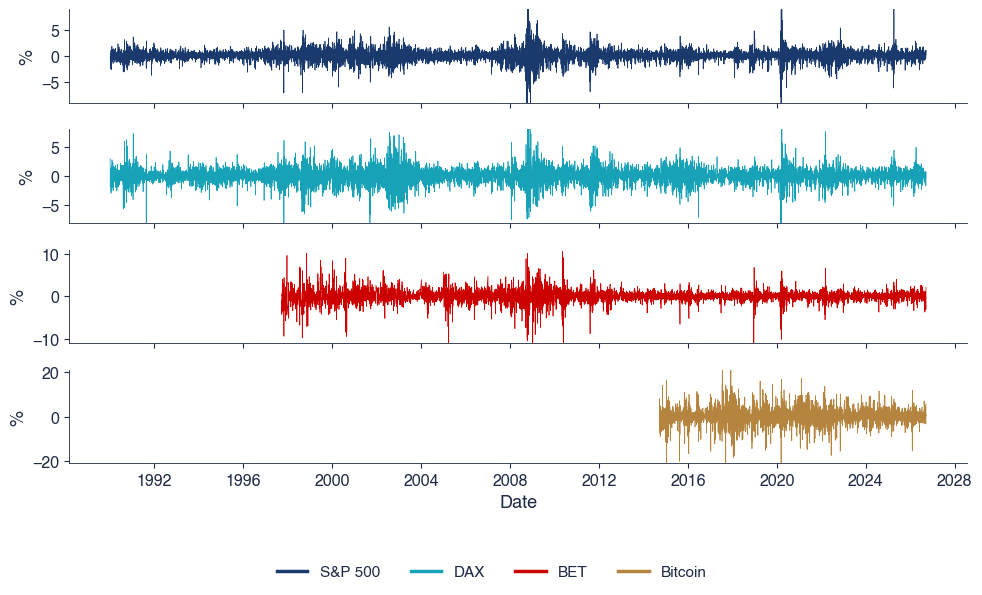

In [7]:
pd.DataFrame(fig_returns_bursts(save=False)).T

## 2. Historical volatility and the window

- Rolling 21-, 63- and 252-day volatility of the S&P 500; the standard error of a sample volatility.

In [8]:
def fig_rolling_windows(k='sp500', windows=WINDOWS, save=True):
    """Rolling 21-, 63- and 252-day volatility of the S&P 500 (annualised, %)."""
    r = returns(k)
    a = ann(r)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    cols = ['#CD0000', '#1A3A6E', '#2E7D32']
    for n, c in zip(windows, cols):
        v = rolling_vol(r, n, a).dropna()
        ax.plot(v.index, v.values, color=c, lw=0.9 if n == 21 else 1.4, label=f'{n}-day window')
        d = v.diff().abs()
        out[str(n)] = {'max': float(v.max()), 'max_date': v.idxmax(), 'min': float(v.min()), 'min_date': v.idxmin(),
                       'mean': float(v.mean()), 'sd_change': float(np.std(np.diff(np.log(v.values)))),
                       'last': float(v.iloc[-1])}
    ax.axhline(r.std() * np.sqrt(a), color='black', lw=0.7, ls='--', label='Whole-sample volatility')
    ax.set_ylabel('Annualised volatility (%)')
    ax.set_xlabel('Date')
    st.legend_outside_bottom(ax, ncol=4, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_rolling_windows')
    out['whole'] = float(r.std() * np.sqrt(a))
    out['ppy'] = a
    return out


def vol_standard_error(k='sp500', ns=(21, 63, 252)):
    """Relative standard error of a sample volatility from n i.i.d. returns: 1/sqrt(2n) under the Normal distribution,
    sqrt((kappa - 1)/(4n)) with kurtosis kappa (delta method)."""
    r = returns(k)
    kappa = float(stats.kurtosis(r, fisher=False))
    return {'kappa': kappa, **{str(n): {'normal': 1 / np.sqrt(2 * n), 'heavy': np.sqrt((kappa - 1) / (4 * n))} for n in ns}}

{'21': {'max': 97.50239715434907,
  'max_date': Timestamp('2020-04-06 00:00:00'),
  'min': 3.4669503667079047,
  'min_date': Timestamp('2017-10-11 00:00:00'),
  'mean': 15.382844945637169,
  'sd_change': 0.06713324785568647,
  'last': 9.625269592719333},
 '63': {'max': 72.50620754231164,
  'max_date': Timestamp('2008-12-11 00:00:00'),
  'min': 5.0506605890543455,
  'min_date': Timestamp('2017-12-13 00:00:00'),
  'mean': 15.837996079186787,
  'sd_change': 0.024619934525413358,
  'last': 11.128742786417243},
 '252': {'max': 45.59362593503096,
  'max_date': Timestamp('2009-07-15 00:00:00'),
  'min': 6.692208524789979,
  'min_date': Timestamp('2017-12-29 00:00:00'),
  'mean': 16.557794982929458,
  'sd_change': 0.007938894565324412,
  'last': 12.89154781528677}}

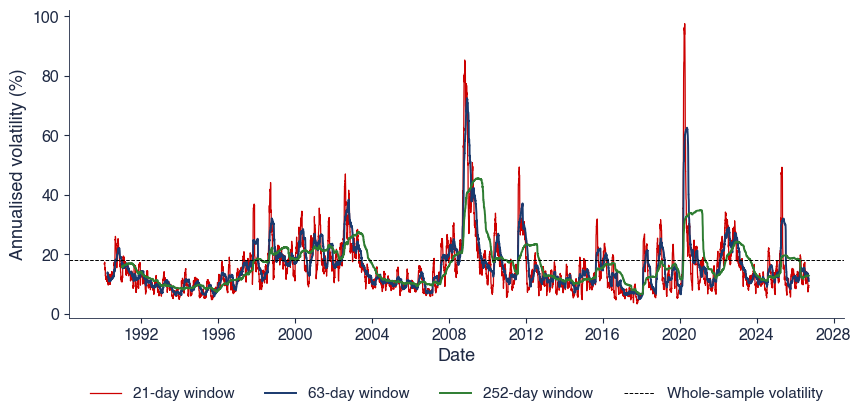

In [9]:
w = fig_rolling_windows(save=False)
{k: v for k, v in w.items() if k in ('21', '63', '252')}

In [10]:
vol_standard_error()

{'kappa': 13.872824529252386,
 '21': {'normal': np.float64(0.1543033499620919),
  'heavy': np.float64(0.39146891455456384)},
 '63': {'normal': np.float64(0.0890870806374748),
  'heavy': np.float64(0.22601468319744802)},
 '252': {'normal': np.float64(0.0445435403187374),
  'heavy': np.float64(0.11300734159872401)}}

## 3. EWMA and the ghost effect

- EWMA weights for $\lambda = 0.94$ and $0.97$ against a 63-day window; half-life $\ln 0.5/\ln\lambda$.
- The 63-day rolling volatility of the S&P 500 drops abruptly in June 2020, when the crash days leave the window.

In [11]:
def fig_ewma_weights(lams=LAMBDAS, n=63, jmax=120, save=True):
    """Weights of past squared returns: EWMA (1 - lam) lam^(j-1) against an equally weighted window of n days."""
    j = np.arange(1, jmax + 1)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for l, c in zip(lams, ['#CD0000', '#1A3A6E']):
        ax.plot(j, (1 - l) * l ** (j - 1), color=c, lw=1.8, label=f'EWMA, lambda = {l}')
    ax.step(j, np.where(j <= n, 1 / n, 0), where='mid', color='#2E7D32', lw=1.6, label=f'Equal weights, {n}-day window')
    ax.set_xlabel('Days in the past (j)')
    ax.set_ylabel('Weight of the squared return')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_ewma_weights')
    return ewma_facts(lams)


def fig_ghost(k='sp500', n=63, lam=0.94, period=GHOST, save=True):
    """The ghost effect: the 63-day rolling volatility drops abruptly when the crash days leave the window; EWMA fades
    smoothly. Absolute returns (annualised scale) for reference."""
    r = returns(k)
    a = ann(r)
    roll = rolling_vol(r, n, a)
    ew = np.sqrt(ewma_series(r, lam) * a)
    s, e = period
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.bar(r.loc[s:e].index, np.abs(r.loc[s:e]) * np.sqrt(a), width=1.0, color='#B5853F', alpha=0.55,
           label='|return|, annualised')
    ax.plot(roll.loc[s:e].index, roll.loc[s:e], color='#1A3A6E', lw=1.8, label=f'{n}-day rolling volatility')
    ax.plot(ew.loc[s:e].index, ew.loc[s:e], color='#CD0000', lw=1.8, label=f'EWMA volatility, lambda = {lam}')
    ax.set_ylabel('Annualised volatility (%)')
    ax.set_xlabel('Date')
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_ghost')
    z = roll.loc['2020-04-01':'2020-09-30']
    d = z.diff()
    drop_day = d.idxmin()
    i = r.index.get_loc(drop_day)
    left = r.index[i - n]           # the return that left the window on drop_day
    ew_z = ew.loc['2020-04-01':'2020-09-30']
    return {'roll_peak': float(roll.loc['2020'].max()), 'roll_peak_date': roll.loc['2020'].idxmax(),
            'ew_peak': float(ew.loc['2020'].max()), 'ew_peak_date': ew.loc['2020'].idxmax(),
            'drop_day': drop_day, 'drop': float(d.min()), 'roll_before': float(z.loc[:drop_day].iloc[-2]),
            'roll_after': float(z.loc[drop_day]), 'left_day': left, 'left_ret': float(r.loc[left]),
            'ew_drop_day': float(ew_z.loc[drop_day] - ew_z.shift().loc[drop_day])}

{'0.94': {'half_life': np.float64(11.202305583621158),
  'mean_lag': 16.666666666666654,
  'days99': np.float64(74.42650729148939),
  'w1': 0.06000000000000005},
 '0.97': {'half_life': np.float64(22.75657306277341),
  'mean_lag': 33.33333333333331,
  'days99': np.float64(151.19139880116785),
  'w1': 0.030000000000000027}}

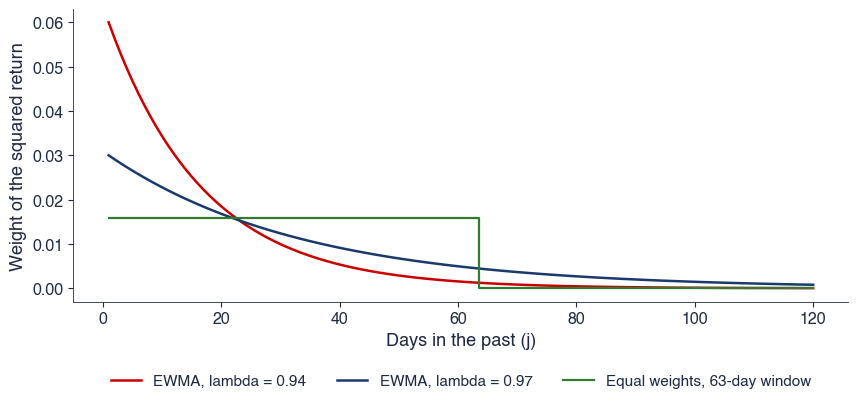

In [12]:
fig_ewma_weights(save=False)

{'roll_peak': 62.56584271790131,
 'roll_peak_date': Timestamp('2020-05-20 00:00:00'),
 'ew_peak': 84.7808204943568,
 'ew_peak_date': Timestamp('2020-03-24 00:00:00'),
 'drop_day': Timestamp('2020-06-15 00:00:00'),
 'drop': -7.392302958467447,
 'roll_before': 50.42499290614944,
 'roll_after': 43.032689947681995,
 'left_day': Timestamp('2020-03-16 00:00:00'),
 'left_ret': -12.76521830653392,
 'ew_drop_day': -0.9333655599995723}

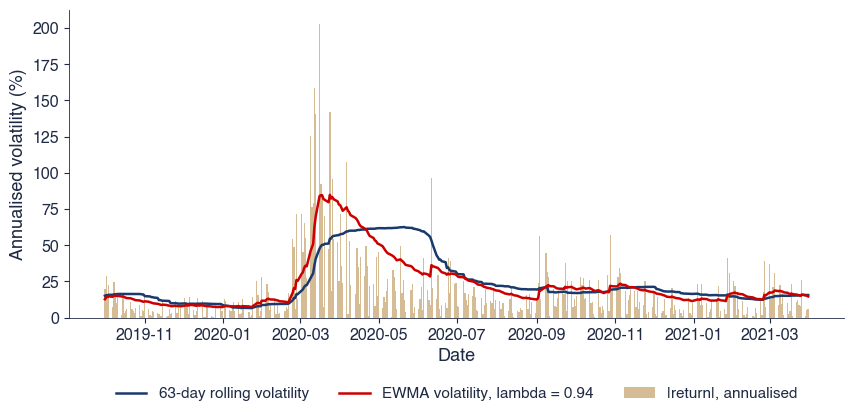

In [13]:
fig_ghost(save=False)

## 4. Range-based estimators

- One simulated trading day with its open, high, low and close.
- Whole-sample estimators for five assets; rolling 21-day estimates of the S&P 500.
- Efficiency by simulation: continuous trading, an overnight jump, discrete trading.

In [14]:
def fig_ohlc_path(seed=3, steps=390, save=True):
    """One simulated trading day (Brownian motion of the log price, 390 one-minute steps) with open, high, low and
    close marked, after an overnight gap."""
    rng = np.random.default_rng(seed)
    x = np.concatenate([[0], np.cumsum(rng.standard_normal(steps) / np.sqrt(steps))])
    o = 0.35
    path = o + x
    fig, ax = plt.subplots(figsize=(10, 3.8))
    m = np.arange(steps + 1)
    ax.plot(m, path, color='#1A3A6E', lw=1.2, label='Log price during the day (%)')
    ax.axhline(0, color='black', lw=0.6, ls=':')
    ih, il = np.argmax(path), np.argmin(path)
    ax.scatter([0], [path[0]], color='#2E7D32', zorder=5, s=40, label='Open O')
    ax.scatter([ih], [path[ih]], color='#CD0000', zorder=5, s=40, label='High H')
    ax.scatter([il], [path[il]], color='#E67E22', zorder=5, s=40, label='Low L')
    ax.scatter([steps], [path[-1]], color='#8E44AD', zorder=5, s=40, label='Close C')
    lo = min(path.min(), 0) - 0.45
    ax.set_ylim(lo, path.max() + 0.15)
    ax.annotate('previous close', xy=(0, 0), xytext=(25, lo + 0.1), color='black', fontsize=10,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))
    ax.set_xlabel('Minutes since the open')
    ax.set_ylabel('ln P - ln C(t-1)  (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_ohlc_path')
    return {'o': o, 'u': float(path[ih] - o), 'd': float(path[il] - o), 'c': float(path[-1] - o)}


def estimators_table(names=OHLC_ASSETS):
    """Whole-sample annualised volatility (%) by estimator; overnight share of the variance; days with high = low."""
    out = {}
    for k in names:
        t = ohlc(k)
        p = range_parts(t)
        a = ann(p['cc'])
        w = window_estimators(p)
        so, sc = p['o'].var(ddof=1), p['c'].var(ddof=1)
        out[k] = {'n': len(p), 'first': p.index[0], 'ppy': a, **{e: float(np.sqrt(v * a)) for e, v in w.items()},
                  'night_share': float(so / (so + sc)), 'zero_range': float(np.mean(t['high'] == t['low'])),
                  'corr_oc': float(np.corrcoef(p['o'], p['c'])[0, 1])}
    return out


def fig_range_rolling(k='sp500', n=21, start='2019-01-01', save=True):
    """Rolling 21-day volatility of the S&P 500 by five estimators (annualised, %), from 2019."""
    p = range_parts(ohlc(k))
    a = ann(p['cc'])
    R = rolling_estimators(p, n)
    V = np.sqrt(R.clip(lower=0) * a).loc[start:]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for e in EST_LABEL:
        ax.plot(V.index, V[e], color=EST_COLORS[e], lw=1.6 if e == 'cc' else 1.0, label=EST_LABEL[e])
    ax.set_ylabel('Annualised volatility (%)')
    ax.set_xlabel('Date')
    st.legend_outside_bottom(ax, ncol=5, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_range_rolling')
    smooth = {e: float(np.std(np.diff(np.log(np.sqrt(R[e].clip(lower=1e-8)))))) for e in EST_LABEL}
    return {'mean': {e: float(V[e].mean()) for e in EST_LABEL}, 'roughness': smooth,
            'corr_cc': {e: float(np.corrcoef(V['cc'], V[e])[0, 1]) for e in EST_LABEL}}


def simulate_ohlc(n_days, sigma=1.0, steps=390, night=0.0, observed=None, rng=None):
    """Simulated daily open, high, low, close (log prices in %): overnight jump N(0, night sigma^2), intraday Brownian
    motion with variance (1 - night) sigma^2 on `steps` steps; with `observed`, only that many equally spaced intraday
    prices are seen (discrete trading). The total daily variance is sigma^2."""
    rng = rng or np.random.default_rng(SEED)
    inc = rng.standard_normal((n_days, steps)) * sigma * np.sqrt((1 - night) / steps)
    path = np.concatenate([np.zeros((n_days, 1)), np.cumsum(inc, axis=1)], axis=1)
    if observed:
        idx = np.unique(np.linspace(0, steps, observed + 1).round().astype(int))
        path = path[:, idx]
    jump = rng.standard_normal(n_days) * sigma * np.sqrt(night)
    close_prev = np.concatenate([[0], np.cumsum(jump + path[:, -1])[:-1]])
    o = close_prev + jump
    return pd.DataFrame({'open': np.exp((o) / 100), 'high': np.exp((o + path.max(axis=1)) / 100),
                         'low': np.exp((o + path.min(axis=1)) / 100), 'close': np.exp((o + path[:, -1]) / 100)})


def efficiency_sim(n=21, windows=1000, steps=4680, scenarios=None, seed=SEED):
    """Monte Carlo: bias and efficiency of the five estimators over windows of n days, true daily volatility 1%;
    intraday Brownian motion on `steps` = 4680 steps (one every 5 seconds of a 6.5-hour session).
    Efficiency = Var(close-to-close estimate) / Var(estimate); MSE ratio = MSE(close-to-close) / MSE(estimate);
    bias = mean estimate / true variance - 1. Scenarios: continuous trading; an overnight jump with 20% of the daily
    variance; discrete trading (26 observed prices per day, one every 15 minutes)."""
    scenarios = scenarios or {'continuous': {}, 'overnight': {'night': 0.2}, 'discrete': {'observed': 26}}
    rng = np.random.default_rng(seed)
    out, draws = {}, {}
    for lab, kw in scenarios.items():
        est = {e: [] for e in EST_LABEL}
        for b in range(windows):
            t = simulate_ohlc(n + 1, steps=steps, rng=rng, **kw)
            w = window_estimators(range_parts(t))
            for e in est:
                est[e].append(w[e])
        est = {e: np.array(v) for e, v in est.items()}
        v_cc, m_cc = np.var(est['cc']), np.mean((est['cc'] - 1) ** 2)
        out[lab] = {e: {'bias': float(np.mean(v) - 1), 'eff': float(v_cc / np.var(v)),
                        'mse_ratio': float(m_cc / np.mean((v - 1) ** 2)),
                        'sd_vol': float(np.std(np.sqrt(np.maximum(v, 0))))} for e, v in est.items()}
        draws[lab] = est
    return out, draws


def fig_efficiency(draws, a=252, save=True):
    """Box plots of the annualised volatility estimates (21-day windows, true volatility 1% per day) in two
    scenarios: continuous trading and an overnight jump."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), sharey=True)
    titles = {'continuous': 'Continuous trading, no overnight jump', 'overnight': 'Overnight jump: 20% of the variance'}
    true = np.sqrt(a)
    for ax, lab in zip(axes, ['continuous', 'overnight']):
        data = [np.sqrt(np.maximum(draws[lab][e], 0) * a) for e in EST_LABEL]
        bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
        for patch, e in zip(bp['boxes'], EST_LABEL):
            patch.set_facecolor(EST_COLORS[e])
            patch.set_alpha(0.55)
            patch.set_edgecolor(EST_COLORS[e])
        for med in bp['medians']:
            med.set_color('black')
        ax.axhline(true, color='black', lw=0.8, ls='--')
        ax.set_xticks(range(1, 6))
        ax.set_xticklabels(['CC', 'P', 'GK', 'RS', 'YZ'])
        ax.set_title(titles[lab], fontsize=11)
    axes[0].set_ylabel('Annualised volatility estimate (%)')
    handles = [plt.Rectangle((0, 0), 1, 1, color=EST_COLORS[e], alpha=0.55) for e in EST_LABEL]
    handles.append(plt.Line2D([0], [0], color='black', ls='--', lw=0.8))
    st.fig_legend_bottom(fig, handles, [EST_LABEL[e] for e in EST_LABEL] + [f'True volatility ({true:.1f}%)'], ncol=6, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_efficiency')

{'o': 0.35,
 'u': 0.8951779445616311,
 'd': -0.4234941872877039,
 'c': 0.6346943744830481}

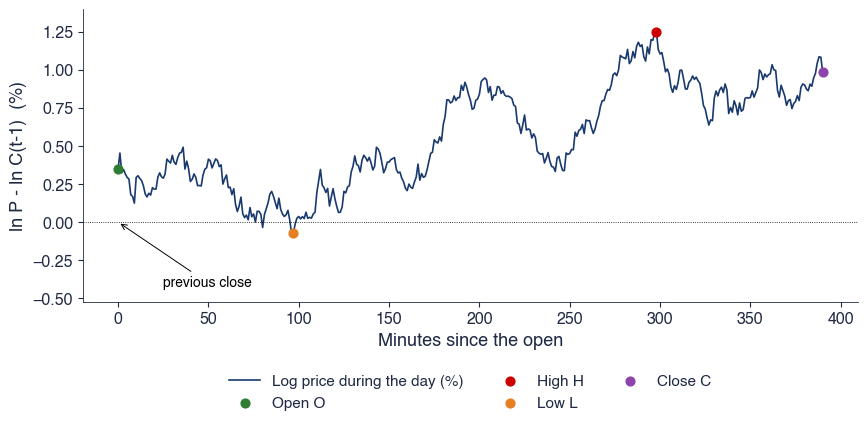

In [15]:
fig_ohlc_path(save=False)

In [16]:
pd.DataFrame(estimators_table()).T

,n,first,ppy,cc,park,gk,rs,yz,night_share,zero_range,corr_oc
sp500,4707,2008-01-03 00:00:00,251.607164,19.859924,15.417802,14.611181,14.399479,16.285433,0.128654,0.0,0.215159
dax,5259,2006-01-03 00:00:00,253.979869,20.864064,16.720549,16.553652,16.568084,20.287655,0.313486,0.00019,0.017737
btc,4384,2014-09-18 00:00:00,365.333333,66.614901,63.532246,62.353401,62.534946,63.224528,0.002976,0.0,0.015602
tlv,4161,2010-01-04 00:00:00,249.107564,26.561402,21.534406,20.606264,20.986179,25.58083,0.258129,0.000961,-0.081368
snp,4178,2010-01-04 00:00:00,250.125307,24.514093,21.436843,20.783219,21.365708,25.8323,0.274273,0.001196,-0.197962


{'mean': {'cc': 16.31658287393578,
  'park': 12.450951744591972,
  'gk': 12.241542571269855,
  'rs': 12.211294014611815,
  'yz': 14.736461481220884},
 'roughness': {'cc': 0.07137327648059034,
  'park': 0.04296302123403713,
  'gk': 0.04166714494243444,
  'rs': 0.04682649026910949,
  'yz': 0.042287604506346506},
 'corr_cc': {'cc': 0.9999999999999999,
  'park': 0.9595673504990037,
  'gk': 0.9532782905520112,
  'rs': 0.9469437963931473,
  'yz': 0.9757731289381346}}

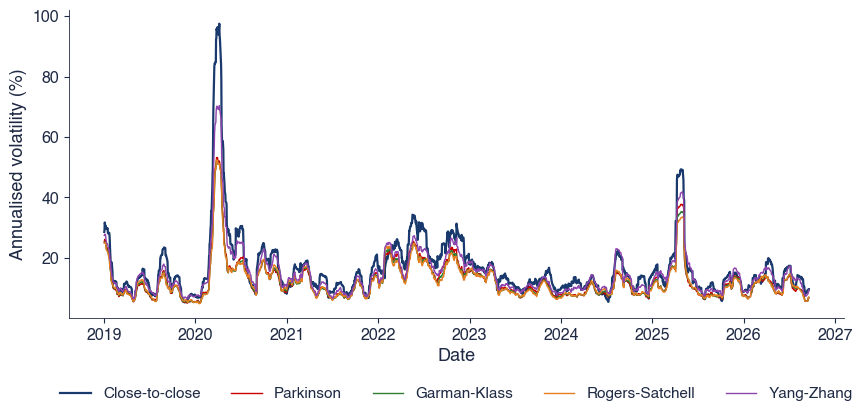

In [17]:
fig_range_rolling(save=False)

bias     eff  mse_ratio  sd_vol
continuous cc   -0.003   1.000      1.000   0.163
           park -0.020   5.407      5.295   0.071
           gk   -0.027   9.283      8.726   0.054
           rs   -0.025   7.611      7.287   0.060
           yz   -0.022   8.528      8.212   0.056
overnight  cc    0.005   1.000      1.000   0.161
           park -0.217   8.831      1.799   0.062
           gk   -0.224  13.598      1.828   0.050
           rs   -0.223  11.030      1.780   0.055
           yz   -0.018   9.241      9.001   0.054
discrete   cc    0.005   1.000      1.000   0.152
           park -0.226   6.096      1.407   0.070
           gk   -0.316  10.805      0.861   0.056
           rs   -0.323   7.936      0.801   0.066
           yz   -0.278   9.359      1.071   0.059

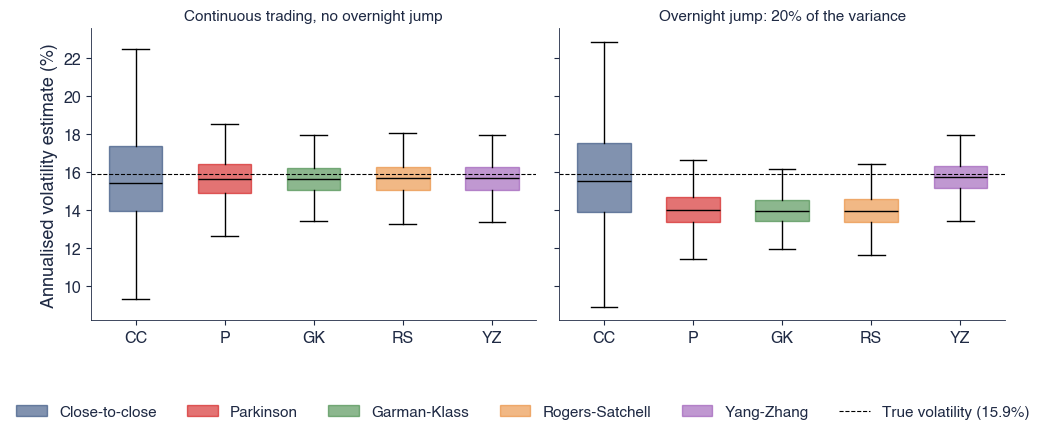

In [18]:
eff, draws = efficiency_sim()
fig_efficiency(draws, save=False)
pd.DataFrame({(sc, e): v for sc, d in eff.items() for e, v in d.items()}).T.round(3)

## 5. Realised volatility (simulated one-minute prices)

- Realised variance $\mathrm{RV}_t = \sum_i r_{t,i}^2$ tracks the true daily variance; microstructure noise inflates RV at high sampling frequencies (signature plot).

In [19]:
def simulate_intraday(days=60, minutes=390, noise=0.0, phi=0.9, eta=0.25, seed=SEED):
    """One-minute log prices (in %) for `days` days: the daily volatility sigma_t follows a log AR(1) (persistence
    phi, shock sd eta), constant within the day; observed prices = true prices + i.i.d. N(0, noise^2) noise.
    Returns the true daily volatility and the observed log-price paths (days x (minutes + 1))."""
    rng = np.random.default_rng(seed)
    ls = np.zeros(days)
    for t in range(1, days):
        ls[t] = phi * ls[t - 1] + eta * rng.standard_normal()
    sig = np.exp(ls)
    inc = rng.standard_normal((days, minutes)) * (sig[:, None] / np.sqrt(minutes))
    start = np.concatenate([[0], np.cumsum(inc.sum(axis=1))[:-1]])
    true = start[:, None] + np.concatenate([np.zeros((days, 1)), np.cumsum(inc, axis=1)], axis=1)
    obs = true + noise * rng.standard_normal(true.shape)
    return sig, obs


def realised_var(paths, every=5):
    """Realised variance of each day: the sum of squared intraday returns sampled every `every` minutes (%^2)."""
    x = paths[:, ::every] if (paths.shape[1] - 1) % every == 0 else np.column_stack([paths[:, ::every], paths[:, -1]])
    return np.sum(np.diff(x, axis=1) ** 2, axis=1)


def fig_realised(days=60, save=True):
    """Simulated month and a half: true daily volatility against sqrt(RV, 5-minute), |daily return| and sqrt(Parkinson)."""
    sig, obs = simulate_intraday(days)
    rv5 = realised_var(obs, 5)
    r = obs[:, -1] - obs[:, 0]
    park = (obs.max(axis=1) - obs.min(axis=1)) ** 2 / (4 * np.log(2))
    fig, ax = plt.subplots(figsize=(10, 3.9))
    d = np.arange(1, days + 1)
    ax.plot(d, sig, color='black', lw=2.0, label='True volatility')
    ax.plot(d, np.sqrt(rv5), color='#CD0000', lw=1.4, marker='o', ms=3, label='sqrt(RV), 5-minute returns')
    ax.plot(d, np.sqrt(park), color='#2E7D32', lw=1.0, ls='--', label='sqrt(Parkinson)')
    ax.scatter(d, np.abs(r), color='#1A3A6E', s=14, zorder=4, label='|daily return|')
    ax.set_xlabel('Day')
    ax.set_ylabel('Daily volatility (%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_realised')
    err = lambda e: float(np.mean(np.abs(np.sqrt(e) - sig) / sig))
    return {'mae_rv5': err(rv5), 'mae_rv1': err(realised_var(obs, 1)), 'mae_r2': err(r ** 2), 'mae_park': err(park),
            'corr_rv5': float(np.corrcoef(np.sqrt(rv5), sig)[0, 1]), 'corr_r': float(np.corrcoef(np.abs(r), sig)[0, 1]),
            'corr_park': float(np.corrcoef(np.sqrt(park), sig)[0, 1])}


def fig_signature(days=500, noise=0.025, every=(1, 2, 3, 5, 10, 15, 30, 65, 130, 390), save=True):
    """Signature plot: the average of RV_t / sigma_t^2 (realised over true daily variance) against the sampling
    interval, without and with microstructure noise (sd 0.025% of the price)."""
    sig, clean = simulate_intraday(days, noise=0.0)
    _, noisy = simulate_intraday(days, noise=noise)
    a = np.array([np.mean(realised_var(clean, m) / sig ** 2) for m in every])
    b = np.array([np.mean(realised_var(noisy, m) / sig ** 2) for m in every])
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(every, a, color='#1A3A6E', marker='o', lw=1.6, label='Prices without noise')
    ax.plot(every, b, color='#CD0000', marker='s', lw=1.6, label='Prices with microstructure noise')
    ax.axhline(1, color='black', lw=0.8, ls='--', label='True variance')
    ax.set_xscale('log')
    ax.set_xticks(every)
    ax.set_xticklabels([str(m) for m in every])
    ax.set_xlabel('Sampling interval (minutes, log scale)')
    ax.set_ylabel('Mean of RV / true variance')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_signature')
    return {'noise': noise, 'clean': dict(zip(map(str, every), a.tolist())), 'noisy': dict(zip(map(str, every), b.tolist())),
            'theory_1min': float(np.mean(1 + 2 * 390 * noise ** 2 / sig ** 2)),
            'theory_5min': float(np.mean(1 + 2 * 78 * noise ** 2 / sig ** 2))}

{'mae_rv5': 0.05937120670436855,
 'mae_rv1': 0.028911719436477586,
 'mae_r2': 0.5813295491983536,
 'mae_park': 0.22785023850215308,
 'corr_rv5': 0.9951940363180076,
 'corr_r': 0.5882319326454323,
 'corr_park': 0.9421789621256061}

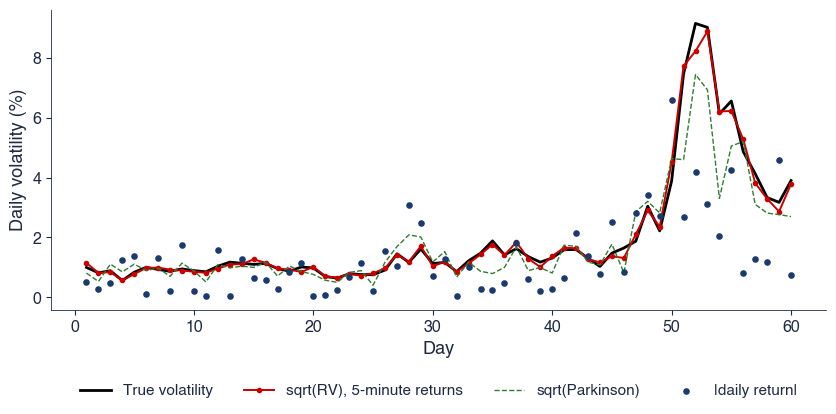

In [20]:
fig_realised(save=False)

{'noise': 0.025,
 'clean': {'1': 0.9970997446970616,
  '2': 0.9998966423520523,
  '3': 0.9957372809659448,
  '5': 0.9975402360842859,
  '10': 1.0046307905838472,
  '15': 1.0044862170378601,
  '30': 0.9990864148965825,
  '65': 0.9817957820132228,
  '130': 1.0163047417341653,
  '390': 1.0878401136103846},
 'noisy': {'1': 1.7875561050578377,
  '2': 1.3963601803490902,
  '3': 1.267471496870758,
  '5': 1.1517667912967127,
  '10': 1.084009365711481,
  '15': 1.055617293173542,
  '30': 1.0275654372151544,
  '65': 0.9916585758422184,
  '130': 1.0205136155832395,
  '390': 1.08246372273325},
 'theory_1min': 1.7881052376713649,
 'theory_5min': 1.1576210475342732}

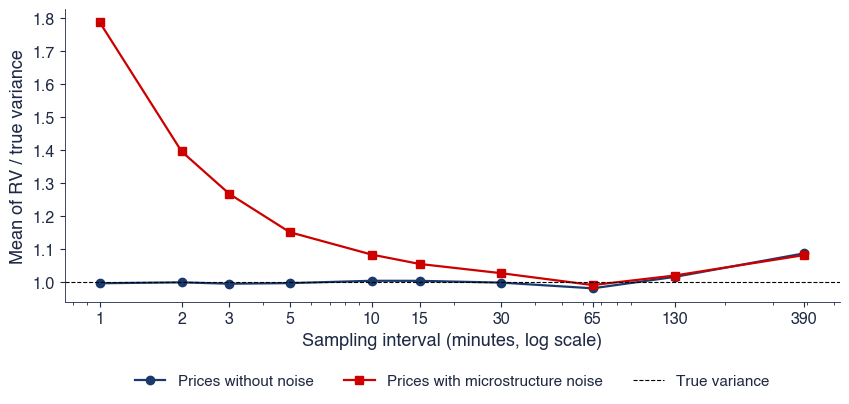

In [21]:
fig_signature(save=False)

## 6. Volatility clustering

- ACF of returns, squared returns and absolute returns; Ljung–Box and ARCH-LM tests; shuffled returns.
- Kurtosis of a variance mixture and of a GARCH(1,1) process (SFEkurgarch).

In [22]:
def clustering_table(names=ASSETS + STOCKS):
    """ACF at lag 1, Ljung-Box Q(10) of returns, squared and absolute returns, ARCH-LM(5), excess kurtosis."""
    out = {}
    for k in names:
        r = returns(k).values
        out[k] = {'n': len(r), 'rho_r': float(acf(r, 1)[0]), 'rho_r2': float(acf(r ** 2, 1)[0]),
                  'rho_abs': float(acf(np.abs(r), 1)[0]), 'lb_r': ljung_box(r), 'lb_r2': ljung_box(r ** 2),
                  'lb_abs': ljung_box(np.abs(r)), 'arch': arch_lm(r), 'exkurt': float(stats.kurtosis(r))}
    return out


def fig_acf_clustering(names=('sp500', 'bet', 'btc'), lags=100, save=True):
    """ACF of returns, squared returns and absolute returns, lags 1-100, with the i.i.d. 95% band."""
    fig, axes = plt.subplots(1, len(names), figsize=(10, 3.7), sharey=True)
    out = {}
    k = np.arange(1, lags + 1)
    for ax, n in zip(axes, names):
        x = returns(n).values
        T = len(x)
        a_r, a_2, a_a = acf(x, lags), acf(x ** 2, lags), acf(np.abs(x), lags)
        ax.plot(k, a_a, color='#CD0000', lw=1.5, label='|returns|')
        ax.plot(k, a_2, color='#2E7D32', lw=1.5, label='Squared returns')
        ax.plot(k, a_r, color='#1A3A6E', lw=1.0, label='Returns')
        band = 1.96 / np.sqrt(T)
        ax.axhspan(-band, band, color='#17A2B8', alpha=0.25, lw=0, label='95% band, i.i.d.')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(NAME[n], fontsize=12)
        ax.set_xlabel('Lag (days)')
        out[n] = {'T': T, 'band': band, 'abs': {str(j): float(a_a[j - 1]) for j in (1, 10, 50, 100)},
                  'sq': {str(j): float(a_2[j - 1]) for j in (1, 10, 50, 100)}, 'ret1': float(a_r[0]),
                  'taylor': float(np.mean(a_a > a_2)), 'out_sq': int(np.sum(np.abs(a_2) > band)),
                  'out_abs': int(np.sum(np.abs(a_a) > band)), 'out_r': int(np.sum(np.abs(a_r) > band))}
    axes[0].set_ylabel('Sample autocorrelation')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_acf_clustering')
    return out


def fig_shuffle(k='sp500', lags=50, seed=SEED, save=True):
    """Clustering is a property of the order of the returns: the same S&P 500 returns in a random order keep their
    distribution (and kurtosis) but lose the clustering."""
    r = returns(k)
    rng = np.random.default_rng(seed)
    s = rng.permutation(r.values)
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.2), gridspec_kw={'width_ratios': [1.6, 1]})
    lim = np.ceil(np.abs(r).max())
    axes[0, 0].plot(r.index, r.values, color='#1A3A6E', lw=0.4, label='S&P 500 returns, actual order')
    axes[1, 0].plot(r.index, s, color='#E67E22', lw=0.4, label='The same returns, random order')
    for ax in axes[:, 0]:
        ax.set_ylim(-lim, lim)
        ax.set_ylabel('%')
    j = np.arange(1, lags + 1)
    band = 1.96 / np.sqrt(len(r))
    for ax, x, c in [(axes[0, 1], r.values, '#1A3A6E'), (axes[1, 1], s, '#E67E22')]:
        ax.bar(j, acf(np.abs(x), lags), color=c, width=0.8)
        ax.axhspan(-band, band, color='#17A2B8', alpha=0.3, lw=0)
        ax.set_ylim(-0.05, 0.42)
        ax.set_ylabel('ACF of |returns|')
    axes[1, 1].set_xlabel('Lag (days)')
    axes[1, 0].set_xlabel('Date')
    st.fig_legend_bottom(fig, [plt.Line2D([0], [0], color=c, lw=2.5) for c in ('#1A3A6E', '#E67E22')],
                         ['S&P 500 returns, actual order', 'The same returns, random order'], ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_shuffle')
    return {'acf1_abs': float(acf(np.abs(r.values), 1)[0]), 'acf1_abs_shuffled': float(acf(np.abs(s), 1)[0]),
            'lb_sq': ljung_box(r.values ** 2)['q'], 'lb_sq_shuffled': ljung_box(s ** 2)['q'],
            'kurt': float(stats.kurtosis(r)), 'kurt_shuffled': float(stats.kurtosis(s))}


def mixture_kurtosis(p, ratio):
    """Kurtosis of a Normal variance mixture: calm days (sd 1) with probability 1 - p, turbulent days (sd = ratio)
    with probability p: kappa = 3 E[sigma^4] / (E[sigma^2])^2."""
    e2 = (1 - p) + p * ratio ** 2
    e4 = (1 - p) + p * ratio ** 4
    return 3 * e4 / e2 ** 2


def garch_kurtosis(a, b):
    """Kurtosis of a GARCH(1,1) process with Normal innovations (SFEkurgarch; Franke, Haerdle and Hafner, Ch. 13):
    kappa = 3 + 6 a^2 / (1 - b^2 - 2ab - 3a^2), finite only if b^2 + 2ab + 3a^2 < 1."""
    den = 1 - b ** 2 - 2 * a * b - 3 * a ** 2
    return np.where(den > 0, 3 + 6 * a ** 2 / np.where(den > 0, den, 1), np.nan)


def fig_kurtosis(save=True):
    """Clustering creates heavy tails: kurtosis of a two-regime variance mixture (left) and of a GARCH(1,1) process
    as a function of alpha for three values of beta (right; as in SFEkurgarch)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    p = np.linspace(0, 1, 201)
    for ratio, c in [(2, '#1A3A6E'), (3, '#CD0000'), (4, '#2E7D32')]:
        axes[0].plot(p, mixture_kurtosis(p, ratio), color=c, lw=1.6, label=f'Mixture, turbulent sd = {ratio} x calm sd')
    axes[0].axhline(3, color='black', lw=0.7, ls='--')
    axes[0].set_xlabel('Share of turbulent days p')
    axes[0].set_ylabel('Kurtosis')
    a = np.linspace(0, 0.2, 401)
    for b, c in [(0.80, '#E67E22'), (0.85, '#8E44AD'), (0.90, '#17A2B8')]:
        axes[1].plot(a, garch_kurtosis(a, b), color=c, lw=1.6, label=f'GARCH(1,1), beta = {b}')
    axes[1].axhline(3, color='black', lw=0.7, ls='--', label='Normal distribution (3)')
    axes[1].set_ylim(2.5, 15)
    axes[1].set_xlabel('alpha (weight of the last squared shock)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_kurtosis')
    return {'mix_02_2': float(mixture_kurtosis(0.2, 2)), 'mix_05_3': float(mixture_kurtosis(0.05, 3)),
            'mix_max_3': float(np.nanmax(mixture_kurtosis(p, 3))), 'mix_argmax_3': float(p[np.nanargmax(mixture_kurtosis(p, 3))]),
            'garch_01_085': float(garch_kurtosis(0.10, 0.85)), 'garch_005_09': float(garch_kurtosis(0.05, 0.90))}

In [23]:
ct = clustering_table()
pd.DataFrame({NAME[k]: {'rho1 r': v['rho_r'], 'rho1 r^2': v['rho_r2'], 'LB(10) r': v['lb_r']['q'], 'LB(10) r^2': v['lb_r2']['q'], 'LB(10) |r|': v['lb_abs']['q'], 'ARCH-LM(5)': v['arch']['lm'], 'R^2': v['arch']['r2'], 'excess kurtosis': v['exkurt']} for k, v in ct.items()}).T.round(3)

,rho1 r,rho1 r^2,LB(10) r,LB(10) r^2,LB(10) |r|,ARCH-LM(5),R^2,excess kurtosis
S&P 500,-0.079,0.311,90.753,8014.689,8323.139,2227.396,0.241,10.873
DAX,-0.009,0.155,21.829,3747.268,5794.381,1209.485,0.130,5.981
BET,0.156,0.333,198.275,2500.373,5183.673,1057.066,0.146,9.864
Bitcoin,-0.022,0.137,20.178,212.745,1086.021,114.666,0.026,11.958
Banca Transilvania,0.010,0.122,29.108,480.618,1179.242,253.149,0.067,13.519
OMV Petrom,-0.015,0.195,20.705,505.071,944.276,234.141,0.061,8.919


{'sp500': {'T': 9240,
  'band': np.float64(0.020390134275123734),
  'abs': {'1': 0.27457690681032093,
   '10': 0.2787745581381446,
   '50': 0.13305439582899498,
   '100': 0.09155859053334124},
  'sq': {'1': 0.3105931079305584,
   '10': 0.24077450339988166,
   '50': 0.057812223838822396,
   '100': 0.03876628842513647},
  'ret1': -0.07868231036241596,
  'taylor': 0.96,
  'out_sq': 100,
  'out_abs': 100,
  'out_r': 20},
 'bet': {'T': 7243,
  'band': np.float64(0.023030153294968055),
  'abs': {'1': 0.4139534511009567,
   '10': 0.23149486114184667,
   '50': 0.11233780790385214,
   '100': 0.10680496401943634},
  'sq': {'1': 0.3331629979255817,
   '10': 0.17651425317713496,
   '50': 0.03878638649891029,
   '100': 0.04547272274133464},
  'ret1': 0.15622675373838288,
  'taylor': 1.0,
  'out_sq': 99,
  'out_abs': 100,
  'out_r': 18},
 'btc': {'T': 4384,
  'band': np.float64(0.02960198257317867),
  'abs': {'1': 0.21265159924664476,
   '10': 0.12046087046314714,
   '50': 0.061423625679099175,
   '

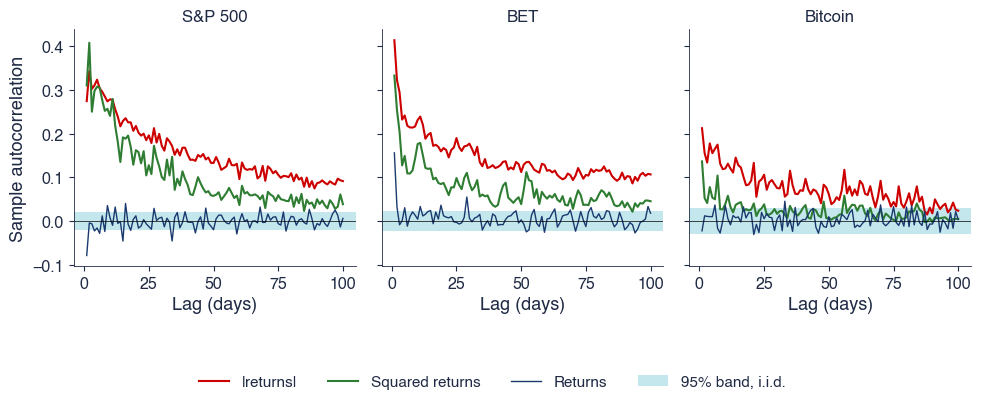

In [24]:
fig_acf_clustering(save=False)

{'acf1_abs': 0.27457690681032093,
 'acf1_abs_shuffled': -0.022549773381426576,
 'lb_sq': 8014.689381207304,
 'lb_sq_shuffled': 6.286347866464504,
 'kurt': 10.872824529252386,
 'kurt_shuffled': 10.872824529252389}

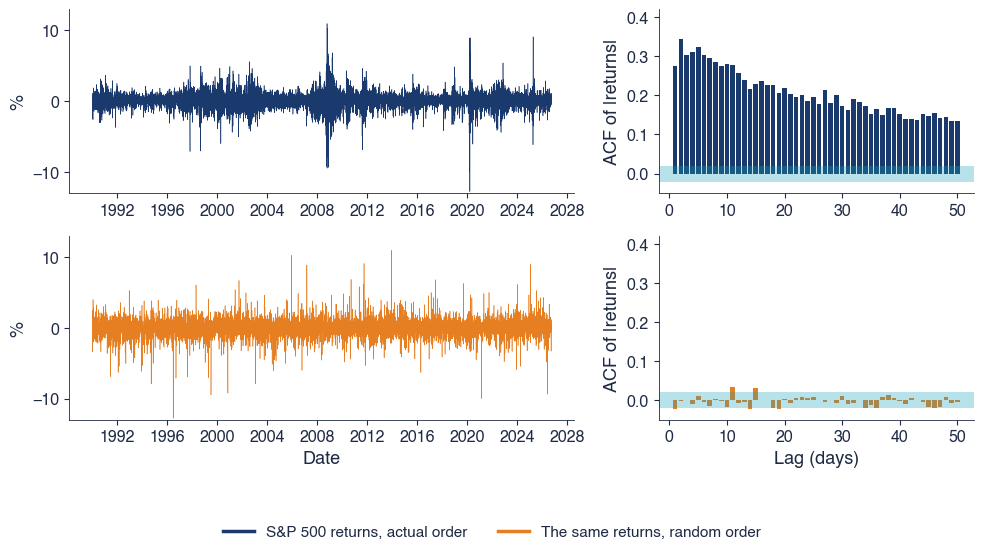

In [25]:
fig_shuffle(save=False)

{'mix_02_2': 4.687499999999999,
 'mix_05_3': 7.653061224489797,
 'mix_max_3': 8.333333333333332,
 'mix_argmax_3': 0.1,
 'garch_01_085': 3.774193548387096,
 'garch_005_09': 3.1621621621621623}

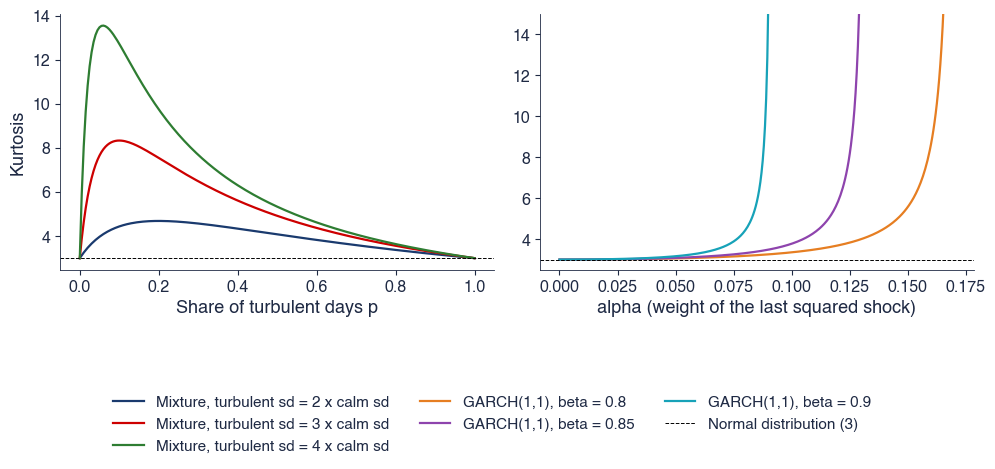

In [26]:
fig_kurtosis(save=False)

## 7. Long-run behaviour, the VIX and the leverage effect

- Annual volatility since 1990; persistence of monthly realised volatility.
- VIX against the realised volatility of the next 21 days.
- corr$(r_t, |r_{t+j}|)$ and the nonparametric volatility given yesterday's return (SFEvolnonparest).

In [27]:
def annual_vol(names=ASSETS):
    """Volatility of each calendar year (annualised with the actual frequency of the series, %)."""
    out = {}
    for k in names:
        r = returns(k)
        a = ann(r)
        g = r.groupby(r.index.year)
        v = g.std() * np.sqrt(a)
        v = v[g.size() >= 100]
        out[k] = v
    return out


def monthly_rv(k='sp500'):
    """Monthly realised volatility sqrt(a x mean of squared daily returns in the month), annualised %, and the AR(1)
    of its logarithm: log RV_m = c + phi log RV_{m-1} + e_m; half-life ln 0.5 / ln phi months."""
    r = returns(k)
    a = ann(r)
    m = np.sqrt((r ** 2).groupby(r.index.to_period('M')).mean() * a)
    lm = np.log(m)
    y, x = lm.values[1:], lm.values[:-1]
    X = np.column_stack([np.ones(len(x)), x])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    se = np.sqrt(np.sum(u ** 2) / (len(y) - 2) * np.linalg.inv(X.T @ X)[1, 1])
    return m, {'phi': float(b[1]), 'c': float(b[0]), 'se': float(se), 'half_life': float(np.log(0.5) / np.log(b[1])),
               'skew_rv': float(stats.skew(m)), 'skew_log': float(stats.skew(lm)), 'mean_rv': float(m.mean()),
               'median_rv': float(m.median()), 'n': len(m), 'long_run': float(np.exp(b[0] / (1 - b[1])))}


def fig_long_term(names=ASSETS, save=True):
    """Annual volatility of four markets since 1990 (left); log monthly realised volatility of the S&P 500 against its
    value in the previous month (right): high volatility persists but reverts to its mean."""
    av = annual_vol(names)
    m, ar = monthly_rv('sp500')
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.0), gridspec_kw={'width_ratios': [1.6, 1]})
    for k in names:
        axes[0].plot(av[k].index, av[k].values, color=COLORS[k], marker='o', ms=3, lw=1.3, label=NAME[k])
    axes[0].set_ylabel('Annual volatility (%)')
    axes[0].set_xlabel('Year')
    lm = np.log(m.values)
    axes[1].scatter(lm[:-1], lm[1:], s=8, color='#1A3A6E', alpha=0.6, label='S&P 500, month m-1 against m')
    g = np.linspace(lm.min(), lm.max(), 50)
    axes[1].plot(g, ar['c'] + ar['phi'] * g, color='#CD0000', lw=1.6, label=f'AR(1) line, phi = {ar["phi"]:.2f}')
    axes[1].plot(g, g, color='black', lw=0.7, ls='--', label='45-degree line')
    axes[1].set_xlabel('log RV, previous month')
    axes[1].set_ylabel('log RV, this month')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_long_term')
    out = {'ar': ar}
    for k in names:
        v = av[k]
        out[k] = {'max': float(v.max()), 'max_year': int(v.idxmax()), 'min': float(v.min()), 'min_year': int(v.idxmin()),
                  'median': float(v.median()), 'y2008': float(v.get(2008, np.nan)), 'y2020': float(v.get(2020, np.nan)),
                  'last': float(v.iloc[-1]), 'last_year': int(v.index[-1])}
    return out


def vix_data(h=21):
    """VIX close and the realised volatility of the S&P 500 over the next h trading days,
    sqrt(a/h x sum_{j=1..h} r_{t+j}^2) (annualised %), and over the past h days, on the S&P 500 calendar."""
    r = returns('sp500')
    a = ann(r)
    v = load_close('vix', START['sp500']).reindex(r.index).ffill()
    r2 = r ** 2
    fwd = np.sqrt(r2[::-1].rolling(h).sum()[::-1].shift(-1) * a / h)
    past = np.sqrt(r2.rolling(h).mean() * a)
    return pd.DataFrame({'vix': v, 'rv_fwd': fwd, 'rv_past': past, 'r': r}).dropna(subset=['vix'])


def fig_vix(save=True):
    """VIX (implied volatility of the S&P 500 for the next 30 calendar days) against the realised volatility of the
    next 21 trading days."""
    d = vix_data()
    z = d.dropna()
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(d.index, d['vix'], color='#CD0000', lw=0.9, label='VIX (implied volatility, %)')
    ax.plot(z.index, z['rv_fwd'], color='#1A3A6E', lw=0.9, label='Realised volatility of the next 21 days (%)')
    ax.set_ylabel('Annualised volatility (%)')
    ax.set_xlabel('Date')
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_vix')
    dv = np.log(d['vix']).diff()
    m = pd.concat([dv, d['r']], axis=1).dropna()
    return {'n': len(z), 'first': d.index[0], 'mean_vix': float(z['vix'].mean()), 'mean_rv': float(z['rv_fwd'].mean()),
            'share_above': float(np.mean(z['vix'] > z['rv_fwd'])), 'gap': float((z['vix'] - z['rv_fwd']).mean()),
            'vrp_var': float((z['vix'] ** 2 - z['rv_fwd'] ** 2).mean()), 'corr': float(np.corrcoef(z['vix'], z['rv_fwd'])[0, 1]),
            'mz_vix': ols(z['rv_fwd'].values, z['vix'].values), 'mz_past': ols(z['rv_fwd'].values, z['rv_past'].values),
            'corr_dvix_r': float(np.corrcoef(m.iloc[:, 0], m.iloc[:, 1])[0, 1]), 'max_vix': float(d['vix'].max()),
            'max_vix_date': d['vix'].idxmax(), 'last_vix': float(d['vix'].iloc[-1])}


def leverage(k, kmax=10):
    """Cross-correlations corr(r_t, |r_{t+j}|) for j = -kmax..kmax (j > 0: today's return and future volatility) and
    the mean squared return of the next day after a negative and after a positive day."""
    r = returns(k)
    x = r.values
    out = {}
    for j in range(-kmax, kmax + 1):
        if j > 0:
            out[j] = float(np.corrcoef(x[:-j], np.abs(x[j:]))[0, 1])
        elif j < 0:
            out[j] = float(np.corrcoef(x[-j:], np.abs(x[:j]))[0, 1])
        else:
            out[j] = float(np.corrcoef(x, np.abs(x))[0, 1])
    nxt = x[1:] ** 2
    neg, pos = nxt[x[:-1] < 0].mean(), nxt[x[:-1] > 0].mean()
    big_neg, big_pos = nxt[x[:-1] < -2].mean(), nxt[x[:-1] > 2].mean()
    return {'cc': out, 'after_neg': float(neg), 'after_pos': float(pos), 'ratio': float(neg / pos),
            'after_big_neg': float(big_neg), 'after_big_pos': float(big_pos), 'n_big_neg': int(np.sum(x[:-1] < -2)),
            'n_big_pos': int(np.sum(x[:-1] > 2))}


def fig_leverage(names=ASSETS, kmax=10, save=True):
    """corr(r_t, |r_{t+j}|): negative for j > 0 in equity indices (bad news raises future volatility)."""
    fig, ax = plt.subplots(figsize=(10, 3.9))
    out = {}
    w = 0.2
    j = np.arange(1, kmax + 1)
    for i, k in enumerate(names):
        L = leverage(k, kmax)
        out[k] = L
        ax.bar(j + (i - 1.5) * w, [L['cc'][jj] for jj in j], width=w, color=COLORS[k], label=NAME[k])
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xticks(j)
    ax.set_xlabel('j (days ahead)')
    ax.set_ylabel('corr( r(t), |r(t+j)| )')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_leverage')
    return out


def quadk(u):
    """Quartic (biweight) kernel 15/16 (1 - u^2)^2 on |u| < 1 (SFEvolnonparest)."""
    return np.where(np.abs(u) < 1, 15 / 16 * (1 - u ** 2) ** 2, 0.0)


def lpregest(X, Y, h, grid):
    """Local linear regression of Y on X with the quartic kernel and bandwidth h, evaluated on `grid`."""
    out = np.empty(len(grid))
    for i, g in enumerate(grid):
        w = quadk((X - g) / h) / h
        d = X - g
        s0, s1, s2 = w.sum(), (w * d).sum(), (w * d * d).sum()
        t0, t1 = (w * Y).sum(), (w * d * Y).sum()
        out[i] = (s2 * t0 - s1 * t1) / (s0 * s2 - s1 ** 2)
    return out


def nonparametric_vol(k, h=0.04, ngrid=100):
    """Conditional volatility as a function of yesterday's return, as in SFEvolnonparest: local linear estimates of
    m1(x) = E[r_t | r_{t-1} = x] and m2(x) = E[r_t^2 | r_{t-1} = x] (decimal returns, quartic kernel, h = 0.04,
    100 grid points from the smallest to the largest return); sigma(x) = sqrt(m2 - m1^2). Returned in %."""
    r = returns(k).values / 100
    X, Y = r[:-1], r[1:]
    grid = np.linspace(X.min(), X.max(), ngrid)
    m1 = lpregest(X, Y, h, grid)
    m2 = lpregest(X, Y ** 2, h, grid)
    return pd.Series(100 * np.sqrt(np.maximum(m2 - m1 ** 2, 0)), index=100 * grid)


def fig_news_impact(names=('sp500', 'dax'), xlim=5, save=True):
    """Nonparametric conditional volatility sigma(x) of today's return given yesterday's return x."""
    fig, ax = plt.subplots(figsize=(10, 3.9))
    out = {}
    for k in names:
        s = nonparametric_vol(k)
        z = s[(s.index > -xlim) & (s.index < xlim)]
        ax.plot(z.index, z.values, color=COLORS[k], lw=1.8, label=NAME[k])
        f = lambda v: float(np.interp(v, s.index, s.values))
        out[k] = {'m2': f(-2), 'p2': f(2), 'zero': f(0), 'min_x': float(z.idxmin()), 'ratio': f(-2) / f(2)}
    ax.axvline(0, color='black', lw=0.6, ls=':')
    ax.set_xlabel("Yesterday's return x (%)")
    ax.set_ylabel("sd of today's return given x (%)")
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_news_impact')
    return out

{'phi': 0.6711226672891477,
 'c': 0.8549531940545857,
 'se': 0.03542157580807794,
 'half_life': 1.7380676150174734,
 'skew_rv': 3.2955184182207504,
 'skew_log': 0.5887679924068024,
 'mean_rv': 15.316090002950338,
 'median_rv': 12.915718275304986,
 'n': 441,
 'long_run': 13.458504208464179}

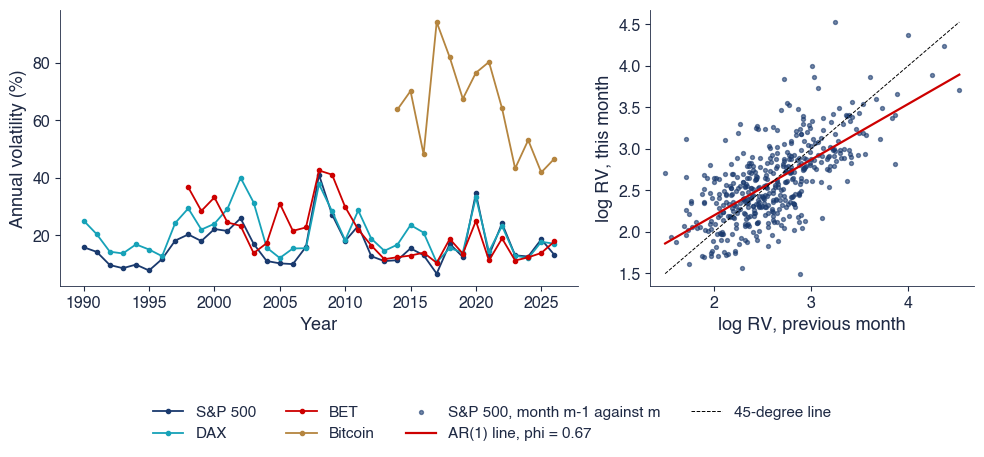

In [28]:
fig_long_term(save=False)['ar']

{'mean_vix': 19.435909337971516,
 'mean_rv': 15.339524294786221,
 'share_above': 0.8584628763996086,
 'corr': 0.7199721821410462,
 'mz_vix': {'a': -1.71581744819282,
  'b': 0.8775170457117943,
  'r2': 0.5183599430569392},
 'mz_past': {'a': 5.185898953704799,
  'b': 0.6614201314403884,
  'r2': 0.43716001817550765},
 'corr_dvix_r': -0.7138425787347438}

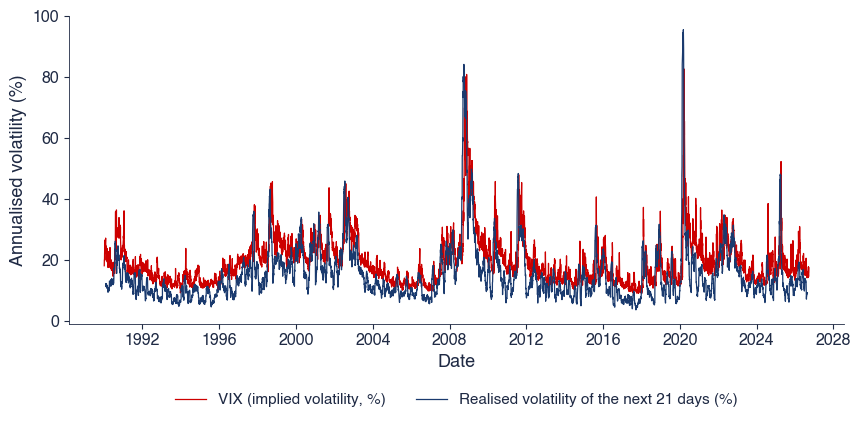

In [29]:
vx = fig_vix(save=False)
{k: vx[k] for k in ['mean_vix', 'mean_rv', 'share_above', 'corr', 'mz_vix', 'mz_past', 'corr_dvix_r']}

{'sp500': (-0.122, 1.51),
 'dax': (-0.114, 1.46),
 'bet': (-0.073, 1.41),
 'btc': (-0.073, 1.06)}

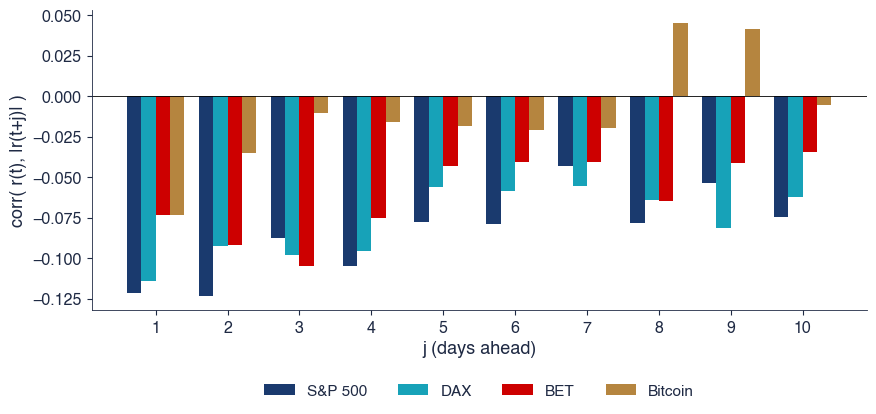

In [30]:
lv = fig_leverage(save=False)
{k: (round(v['cc'][1], 3), round(v['ratio'], 2)) for k, v in lv.items()}

{'sp500': {'m2': 1.6143530699164932,
  'p2': 1.1638978233548791,
  'zero': 1.0435027672633228,
  'min_x': 0.65352106227691,
  'ratio': 1.3870230165593047},
 'dax': {'m2': 1.7885534041183202,
  'p2': 1.428782446451937,
  'zero': 1.279466737194948,
  'min_x': 0.6782969250088117,
  'ratio': 1.2518024759891153}}

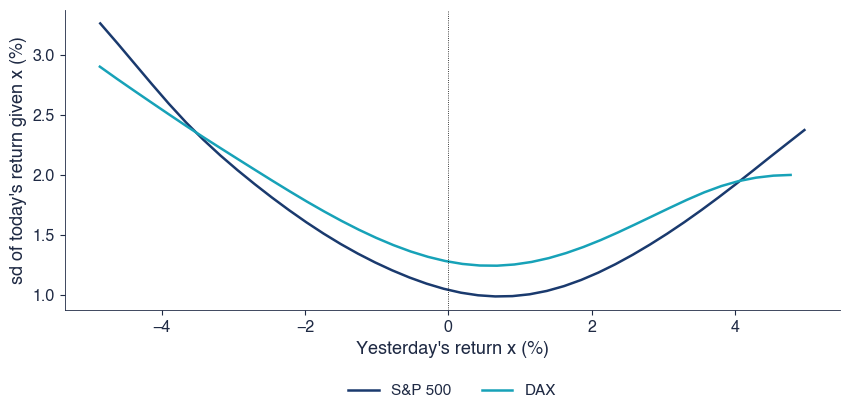

In [31]:
fig_news_impact(save=False)

## 8. Evaluating volatility forecasts

- Next-day variance forecasts of the S&P 500 from 2010: rolling windows, EWMA, VIX; MSE, QLIKE, Mincer–Zarnowitz, Diebold–Mariano.
- The best $\lambda$ by QLIKE for the S&P 500, BET and Bitcoin.

In [32]:
def forecast_table(k='sp500'):
    """Losses (two proxies) and Mincer-Zarnowitz R^2 of the forecasts of the S&P 500 from 2010."""
    F = forecasts(k)
    return {'n': len(F), 'first': F.index[0], 'r2': losses(F, 'r2'), 'range': losses(F, 'range'), 'mz': mz_table(F),
            'dm_vix_ewma': dm_test(F, 'vix', 'ewma94'), 'dm_ewma_hist21': dm_test(F, 'ewma94', 'hist21'),
            'dm_ewma_hist252': dm_test(F, 'ewma94', 'hist252')}


def fig_lambda(names=('sp500', 'bet', 'btc'), save=True):
    """QLIKE of EWMA forecasts against lambda (difference from the minimum), with the best lambda marked."""
    fig, ax = plt.subplots(figsize=(10, 3.8))
    out = {}
    for k in names:
        q = lambda_qlike(k)
        best = float(q.idxmin())
        ax.plot(q.index, q - q.min(), color=COLORS[k], lw=1.8, label=f'{NAME[k]} (best lambda = {best:.3f})')
        ax.scatter([best], [0], color=COLORS[k], s=40, zorder=5)
        out[k] = {'best': best, 'q094': float(q.loc[0.94] - q.min()), 'q097': float(q.loc[0.97] - q.min())}
    ax.axvline(0.94, color='black', lw=0.7, ls='--', label='RiskMetrics, 0.94')
    ax.set_xlabel('lambda')
    ax.set_ylabel('QLIKE minus its minimum')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_lambda')
    return out


def fig_forecast_paths(k='sp500', period=('2020-01-01', '2020-12-31'), save=True):
    """Next-day volatility forecasts in 2020: 252-day window, EWMA 0.94 and VIX, against |r_t| (annualised %)."""
    F = forecasts(k, start='2019-01-01')
    a = ann(returns(k))
    z = F.loc[period[0]:period[1]]
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.bar(z.index, np.sqrt(z['r2'] * a), width=1.0, color='#B5853F', alpha=0.55, label='|return|, annualised')
    for m, c, lab in [('hist252', '#2E7D32', '252-day window'), ('ewma94', '#CD0000', 'EWMA, lambda = 0.94'),
                      ('vix', '#1A3A6E', 'VIX')]:
        ax.plot(z.index, np.sqrt(z[m] * a), color=c, lw=1.6, label=lab)
    ax.set_ylabel('Annualised volatility (%)')
    ax.set_xlabel('Date')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch8_forecast_paths')

In [33]:
ft = forecast_table()
print(ft['dm_vix_ewma'], ft['dm_ewma_hist21'])
pd.DataFrame({m: {'MSE': ft['r2'][m]['mse'], 'QLIKE': ft['r2'][m]['qlike'], 'MZ R^2 (r^2)': ft['mz'][m]['r2']['r2'], 'MZ R^2 (range)': ft['mz'][m]['range']['r2']} for m in ft['r2']}).T.round(4)

{'d': -0.008341660216265796, 't': -0.316943542616462, 'p': 0.7512864416939319} {'d': -0.06843568818172104, 't': -4.49577176324768, 'p': 6.93180602566845e-06}


,MSE,QLIKE,MZ R^2 (r^2),MZ R^2 (range)
hist21,18.9873,0.8761,0.1403,0.2377
hist63,20.7651,0.9144,0.0509,0.0901
hist252,21.4327,1.0987,0.0081,0.0194
ewma94,17.7717,0.8076,0.1678,0.2895
ewma97,19.0161,0.8443,0.1078,0.1894
vix,16.6974,0.7993,0.2513,0.4181


{'sp500': {'best': 0.925,
  'q094': 0.0024570384357730513,
  'q097': 0.039113516038176144},
 'bet': {'best': 0.885,
  'q094': 0.021510046212195433,
  'q097': 0.0727986966654246},
 'btc': {'best': 0.97, 'q094': 0.01997377881314577, 'q097': 0.0}}

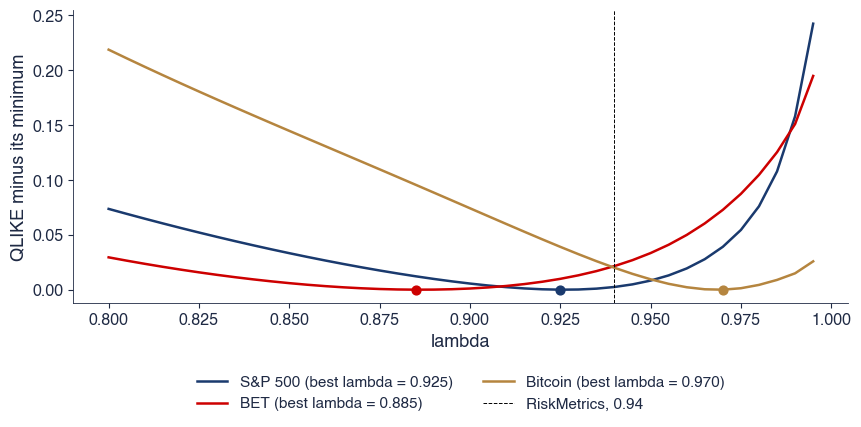

In [34]:
fig_lambda(save=False)

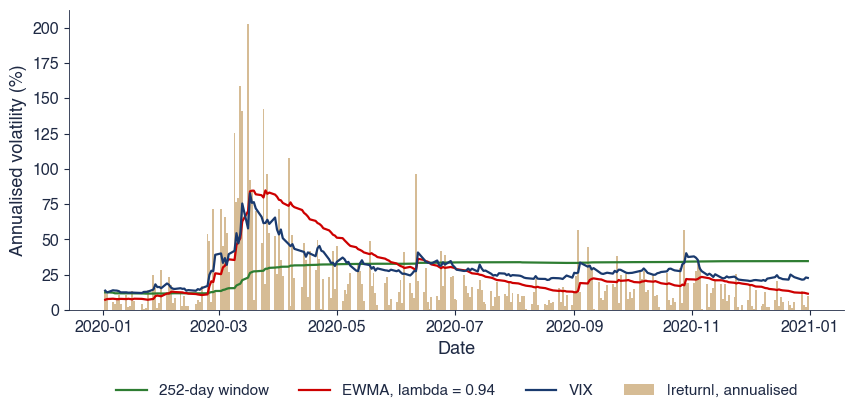

In [35]:
fig_forecast_paths(save=False)

## 9. AI for scientific discovery: range-based estimators on the BVB

- Open question: do range-based estimators help on the Bucharest Stock Exchange, where many stocks trade thinly?
- Starter result: share of days with an unchanged close, ratios to close-to-close, QLIKE of next-day forecasts.
- Check before trusting any answer, yours or an AI's: the constants of each estimator, adjusted OHLC prices, the annualisation, no look-ahead in the forecasts.

In [36]:
def bvb_range(names=BVB + ['sp500'], n=21, start=OOS_START):
    """For each stock: share of trading days (volume > 0) with an unchanged close (a sign of thin trading), share of
    days with high = low, ratio of Parkinson and Yang-Zhang volatility to close-to-close,
    and the QLIKE (proxy r^2) of next-day forecasts by the 21-day close-to-close, Parkinson and Yang-Zhang variance."""
    out = {}
    for k in names:
        t = ohlc(k)
        p = range_parts(t)
        w = window_estimators(p)
        R = rolling_estimators(p, n).shift(1).loc[start:].dropna()
        y = (p['cc'] ** 2).reindex(R.index)
        q = {e: float(np.mean(y / R[e].clip(lower=1e-6) + np.log(R[e].clip(lower=1e-6)))) for e in ['cc', 'park', 'yz']}
        raw = read_market(SERIES[k][0]).loc[OHLC_START.get(k) or SERIES[k][4]:END]
        raw = raw[raw.index.dayofweek < 5]
        flat = float(np.mean((raw['close'].diff() == 0) & (raw['volume'] > 0)))
        out[k] = {'zero_range': float(np.mean(t['high'] == t['low'])), 'flat': flat, 'park_cc': float(np.sqrt(w['park'] / w['cc'])),
                  'yz_cc': float(np.sqrt(w['yz'] / w['cc'])), 'qlike': q, 'n': len(R)}
    return out

In [37]:
pd.DataFrame({k: {'unchanged close': v['flat'], 'P/CC': v['park_cc'], 'YZ/CC': v['yz_cc'], **{f'QLIKE {e}': q for e, q in v['qlike'].items()}} for k, v in bvb_range().items()}).T.round(3)

,unchanged close,P/CC,YZ/CC,QLIKE cc,QLIKE park,QLIKE yz
tlv,0.087,0.811,0.963,2.022,2.185,2.039
snp,0.079,0.874,1.054,1.866,1.864,1.791
brd,0.097,0.896,1.098,1.905,1.940,1.872
tgn,0.103,0.872,1.043,1.750,1.744,1.636
sp500,0.000,0.776,0.820,0.880,1.009,0.890
